In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import DateFormatter
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [6]:
#file_path = "June_2023_Data.csv"  
#df = pd.read_csv(file_path)

In [237]:
file_path = "December_2024_Data.csv"  
df = pd.read_csv(file_path)
print(f"Loaded {len(df)} rows from {file_path}")

Loaded 452 rows from December_2024_Data.csv


In [238]:
# STEP 1: inspect and parse datetime

# See the raw strings
print("Raw datetime sample:")
print(df['datetime'].head(10).to_list())
print("Raw dtype:", df['datetime'].dtype)

# Robust parsing (let pandas guess the format)
dt_raw = df['datetime'].astype(str).str.strip()

df['datetime'] = pd.to_datetime(
    dt_raw,
    errors='coerce',              
    dayfirst=False,              
    infer_datetime_format=True
)

df = df.sort_values('datetime').reset_index(drop=True)

print("\nAfter parsing:")
print(df['datetime'].head(10).to_list())
print("NaT count:", df['datetime'].isna().sum())
print("Parsed dtype:", df['datetime'].dtype)

Raw datetime sample:
['2024-12-02 09:15:00', '2024-12-02 09:30:00', '2024-12-02 09:45:00', '2024-12-02 10:00:00', '2024-12-02 10:15:00', '2024-12-02 10:30:00', '2024-12-02 10:45:00', '2024-12-02 11:00:00', '2024-12-02 11:15:00', '2024-12-02 11:30:00']
Raw dtype: object

After parsing:
[Timestamp('2024-12-02 09:15:00'), Timestamp('2024-12-02 09:30:00'), Timestamp('2024-12-02 09:45:00'), Timestamp('2024-12-02 10:00:00'), Timestamp('2024-12-02 10:15:00'), Timestamp('2024-12-02 10:30:00'), Timestamp('2024-12-02 10:45:00'), Timestamp('2024-12-02 11:00:00'), Timestamp('2024-12-02 11:15:00'), Timestamp('2024-12-02 11:30:00')]
NaT count: 0
Parsed dtype: datetime64[ns]


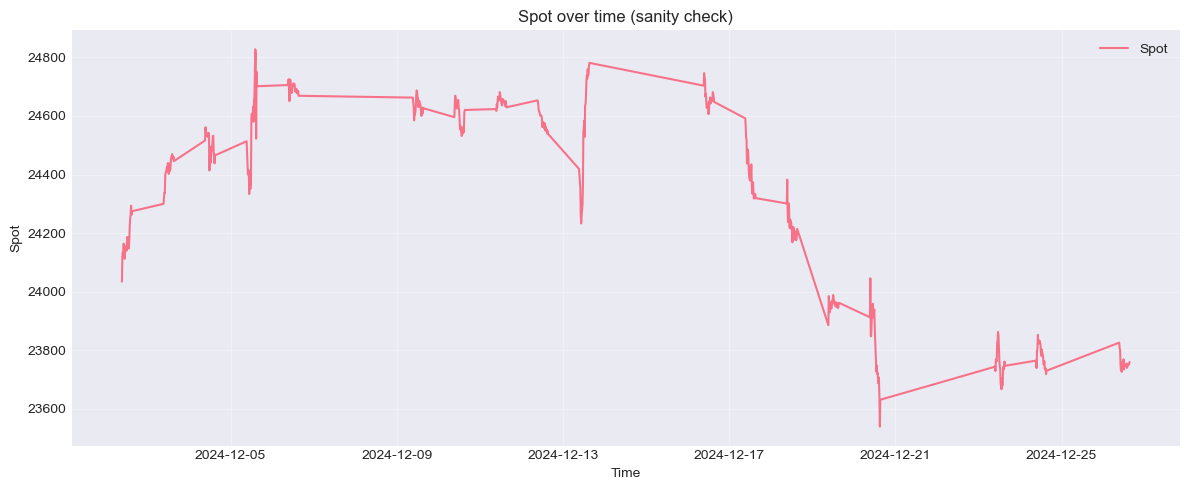

In [239]:
# STEP 3: sanity-check chart

import matplotlib.pyplot as plt

tmp = df.dropna(subset=['datetime', 'spot']).copy()
tmp = tmp.sort_values('datetime')

plt.figure(figsize=(12, 5))
plt.plot(tmp['datetime'], tmp['spot'], label='Spot', linewidth=1.5)
plt.xlabel('Time')
plt.ylabel('Spot')
plt.title('Spot over time (sanity check)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [240]:
print(f"Loaded {len(df)} rows from {file_path}")

Loaded 452 rows from December_2024_Data.csv


In [43]:
# Parse and sort
#df['datetime'] = pd.to_datetime(df['datetime'], dayfirst=True)
#df = df.sort_values('datetime').reset_index(drop=True)

# FIXED DATETIME PARSING (handles all common formats)
#df['datetime'] = pd.to_datetime(df['datetime'], format='%d-%m-%Y %H:%M:%S', errors='coerce')
#df = df.sort_values('datetime').reset_index(drop=True)

# Check for parsing issues
#print(f"Parsed rows: {len(df)}")
#print(f"NaT datetime rows: {(df['datetime'].isna()).sum()}")

#if df['datetime'].isna().sum() > 0:
#    print("Sample bad dates:")
#    print(df[df['datetime'].isna()]['datetime'].head())

# Parse and sort with correct format
#df['datetime'] = pd.to_datetime(
#    df['datetime'],
#    format='%Y-%m-%d %H:%M:%S',   # <- key change
#    errors='raise'                # temporarily, to catch mistakes
#)
#df = df.sort_values('datetime').reset_index(drop=True)
#
#print(f"Parsed rows: {len(df)}")
#print(f"NaT datetime rows: {df['datetime'].isna().sum()}")
#print(df['datetime'].head())

In [241]:
# STEP 2: COMPUTE ALL FEATURES
# ===========================================
print("\nComputing features...")

# Changes (deltas)
df['d_call_oi'] = df['CALL_oi'].diff()
df['d_put_oi']  = df['PUT_oi'].diff()
df['d_call_iv'] = df['CALL_iv'].diff()
df['d_put_iv']  = df['PUT_iv'].diff()
df['d_call_close'] = df['CALL_close'].diff()
df['d_put_close']  = df['PUT_close'].diff()


Computing features...


In [242]:
# Skew
df['skew'] = df['PUT_iv'] - df['CALL_iv']

In [243]:
# Future returns (30m = 2 bars ahead)
df['spot_ret_30m'] = df['spot'].pct_change(2).shift(-2) * 100
df['spot_ret_60m'] = df['spot'].pct_change(4).shift(-4) * 100
df['spot_abs_30m'] = df['spot_ret_30m'].abs()
df['direction_30m'] = (df['spot_ret_30m'] > 0).astype(int)

df['call_ret_30m'] = df['CALL_close'].pct_change(2).shift(-2) * 100
df['put_ret_30m']  = df['PUT_close'].pct_change(2).shift(-2) * 100
# OI imbalance
denom = (df['d_call_oi'].abs() + df['d_put_oi'].abs()).replace(0, np.nan)
df['oi_imbalance'] = (df['d_call_oi'] - df['d_put_oi']) / denom

In [244]:
# Time features
df['hour'] = df['datetime'].dt.hour
df['time_bucket'] = df['datetime'].dt.strftime('%H:%M')
#df['weekday'] = df['datetime'].dt.weekday_name
df['weekday'] = df['datetime'].dt.day_name()

In [245]:
# Drop NaNs
df_clean = df.dropna(subset=[
    'spot_ret_30m', 'spot_abs_30m', 'direction_30m',
    'd_call_oi', 'd_put_oi', 'oi_imbalance'
]).reset_index(drop=True)

print(f"Clean data: {len(df_clean)} rows")

Clean data: 447 rows


In [246]:
# STEP 3: EVENT ANALYSIS (TABLES)
# ===========================================

# OI Events
call_thr = df_clean['d_call_oi'].quantile(0.8)
put_thr  = df_clean['d_put_oi'].quantile(0.8)
call_build = df_clean['d_call_oi'] > call_thr
put_build  = df_clean['d_put_oi'] > put_thr

def event_summary(mask, name):
    g = df_clean[mask].copy()
    if len(g) == 0: return [name, 0, np.nan, np.nan, np.nan, np.nan, np.nan]
    return [name, len(g), 
            f"{g['spot_ret_30m'].mean():.2f}%", 
            f"{(g['direction_30m']==1).mean()*100:.1f}%",
            f"{g['call_ret_30m'].mean():.2f}%",
            f"{g['put_ret_30m'].mean():.2f}%",
            f"{g['spot_abs_30m'].mean():.2f}%"]

rows_oi = []
rows_oi.append(event_summary(call_build, "CALL OI build-up"))
rows_oi.append(event_summary(put_build, "PUT OI build-up"))
rows_oi.append(event_summary(df_clean['oi_imbalance']>0.3, "CALL dominant"))
rows_oi.append(event_summary(df_clean['oi_imbalance']<-0.3, "PUT dominant"))

report_oi = pd.DataFrame(rows_oi, columns=[
    "Event", "Count", "Spot 30m %", "Spot up %", "CALL 30m %", "PUT 30m %", "|Spot| 30m %"
])

In [247]:
# IV Events (FIXED)
df_clean['call_iv_abs'] = df_clean['d_call_iv'].abs()
df_clean['put_iv_abs']  = df_clean['d_put_iv'].abs()
iv_thr_call = df_clean['call_iv_abs'].quantile(0.9)
iv_thr_put  = df_clean['put_iv_abs'].quantile(0.9)
iv_spike = (df_clean['call_iv_abs'] > iv_thr_call) | (df_clean['put_iv_abs'] > iv_thr_put)

rows_iv = []
for mask, name in [(iv_spike, "IV spike"), (~iv_spike, "Normal")]:
    g = df_clean[mask]
    rows_iv.append([name, len(g), f"{g['spot_abs_30m'].mean():.2f}%", f"{g['spot_abs_30m'].median():.2f}%"])

report_iv = pd.DataFrame(rows_iv, columns=["Event", "Count", "Avg |Spot| 30m %", "Median |Spot| 30m %"])

print("\n=== OI EVENTS ===")
print(report_oi)
print("\n=== IV EVENTS ===")
print(report_iv)


=== OI EVENTS ===
              Event  Count Spot 30m % Spot up % CALL 30m % PUT 30m %  \
0  CALL OI build-up     90     -0.02%     48.9%     -4.99%    -3.80%   
1   PUT OI build-up     90     -0.01%     48.9%     -7.08%    -2.99%   
2     CALL dominant    124      0.00%     42.7%      0.27%    -3.01%   
3      PUT dominant    112     -0.02%     48.2%     -3.67%     0.56%   

  |Spot| 30m %  
0        0.14%  
1        0.14%  
2        0.14%  
3        0.14%  

=== IV EVENTS ===
      Event  Count Avg |Spot| 30m % Median |Spot| 30m %
0  IV spike     62            0.17%               0.10%
1    Normal    385            0.13%               0.08%


In [248]:
# Time of day (FIXED)
oi_signal_by_time = df_clean[df_clean['oi_imbalance'].abs() > 0.3].groupby('time_bucket').size()
print(f"\nTop 10 OI signal times:\n{oi_signal_by_time.sort_values(ascending=False).head(10)}")


Top 10 OI signal times:
time_bucket
11:00    12
11:15    12
10:45    11
13:15    11
14:30    11
13:45    11
14:00    11
13:00    11
14:15    10
14:45    10
dtype: int64


In [249]:
# STEP 5: SAVE EXCEL REPORT
# ===========================================
with pd.ExcelWriter('DEC2025_ATM_Report.xlsx') as writer:
    report_oi.to_excel(writer, sheet_name='OI_Events', index=False)
    report_iv.to_excel(writer, sheet_name='IV_Events', index=False)
    
    # Time analysis
    time_summary = df_clean.groupby('time_bucket').agg({
        'oi_imbalance': 'count',
        'spot_ret_30m': 'mean'
    }).round(3)
    time_summary.to_excel(writer, sheet_name='Time_Patterns')
    
    # Raw sample
    df_sample = df_clean[['datetime', 'spot', 'CALL_close', 'PUT_close', 
                         'CALL_iv', 'PUT_iv', 'CALL_oi', 'PUT_oi',
                         'oi_imbalance', 'spot_ret_30m']].head(1000)
    df_sample.to_excel(writer, sheet_name='Sample_Data', index=False)

print("\n✅ SAVED:")
print("   FEB2023_ALL_CHARTS.png")
print("   FEB2023_ATM_Report.xlsx")
print("\n🎉 February 2023 analysis COMPLETE!")


✅ SAVED:
   FEB2023_ALL_CHARTS.png
   FEB2023_ATM_Report.xlsx

🎉 February 2023 analysis COMPLETE!


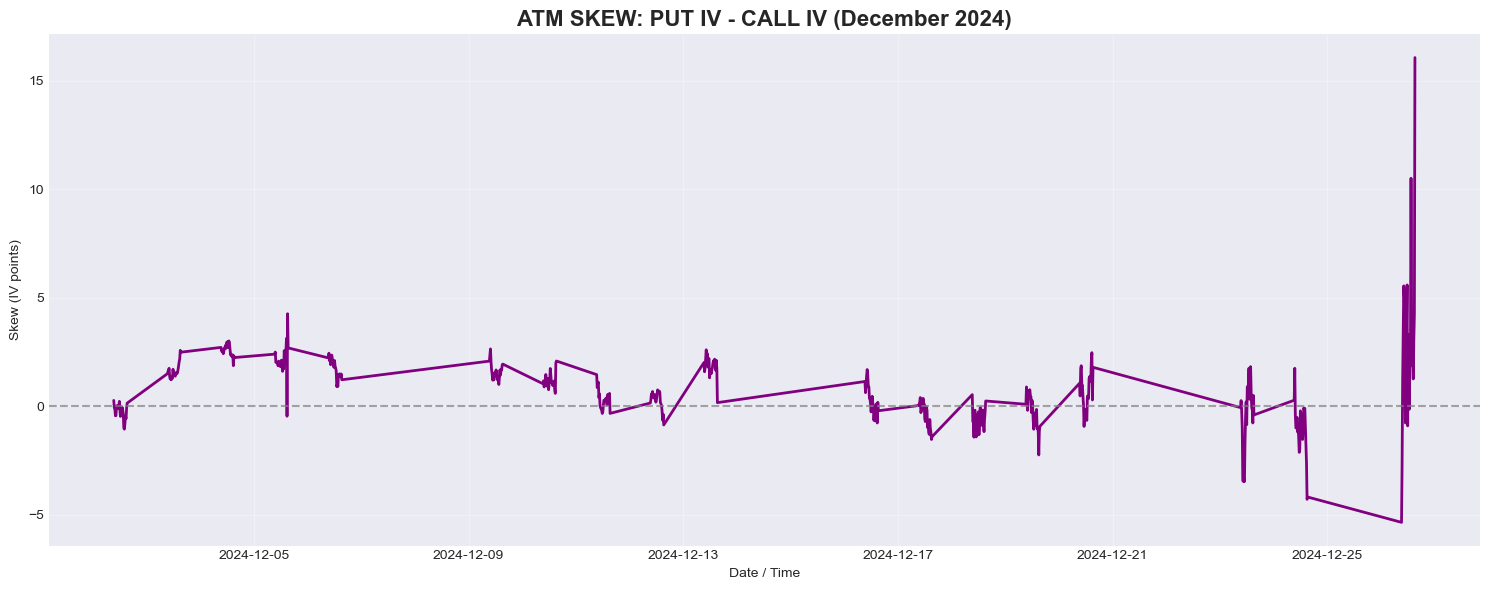

In [251]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 6))

# Skew = PUT IV - CALL IV
df['skew'] = df['PUT_iv'] - df['CALL_iv']

plt.plot(df.set_index('datetime')['skew'], linewidth=2, color='purple')
plt.axhline(0, color='grey', linestyle='--', alpha=0.7)
plt.title('ATM SKEW: PUT IV - CALL IV (December 2024)', fontsize=16, fontweight='bold')
plt.xlabel('Date / Time')
plt.ylabel('Skew (IV points)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

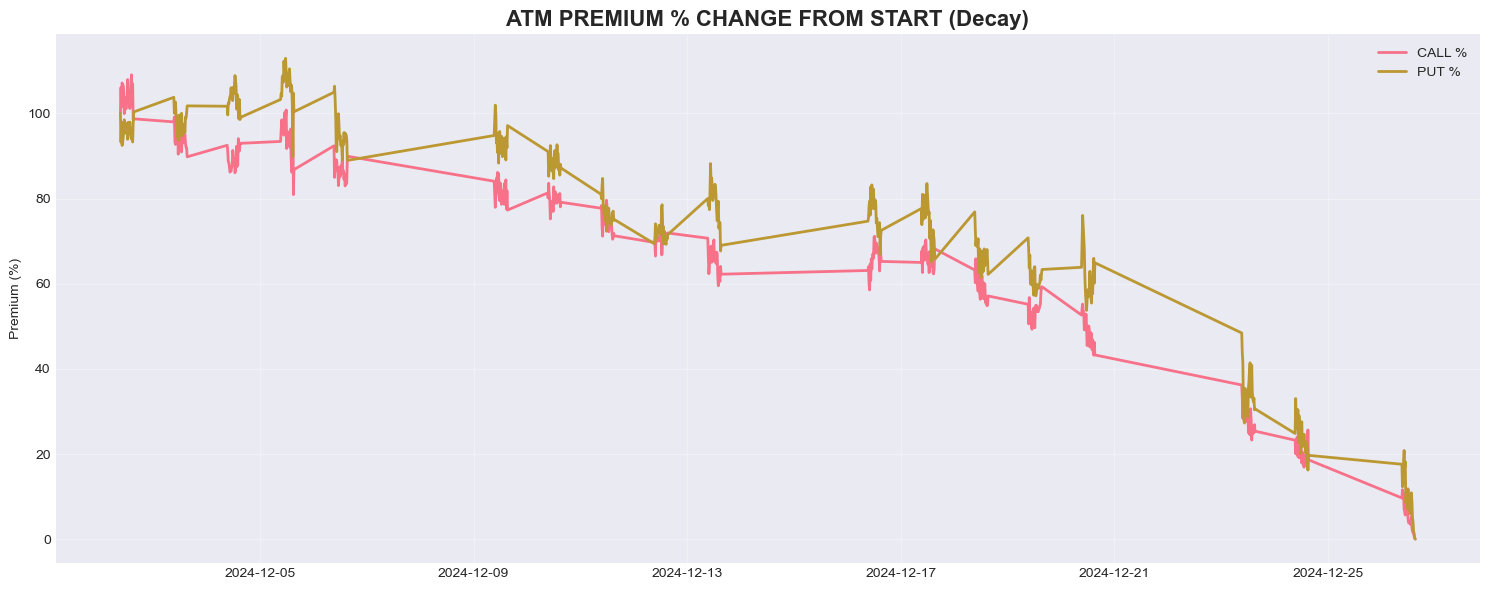

In [252]:
plt.figure(figsize=(15, 6))

# % from first day (makes decay clear)
df['call_pct'] = df['CALL_close'] / df['CALL_close'].iloc[0] * 100
df['put_pct']  = df['PUT_close'] / df['PUT_close'].iloc[0] * 100

plt.plot(df.set_index('datetime')['call_pct'], label='CALL %', linewidth=2)
plt.plot(df.set_index('datetime')['put_pct'], label='PUT %', linewidth=2)
plt.title('ATM PREMIUM % CHANGE FROM START (Decay)', fontsize=16, fontweight='bold')
plt.ylabel('Premium (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

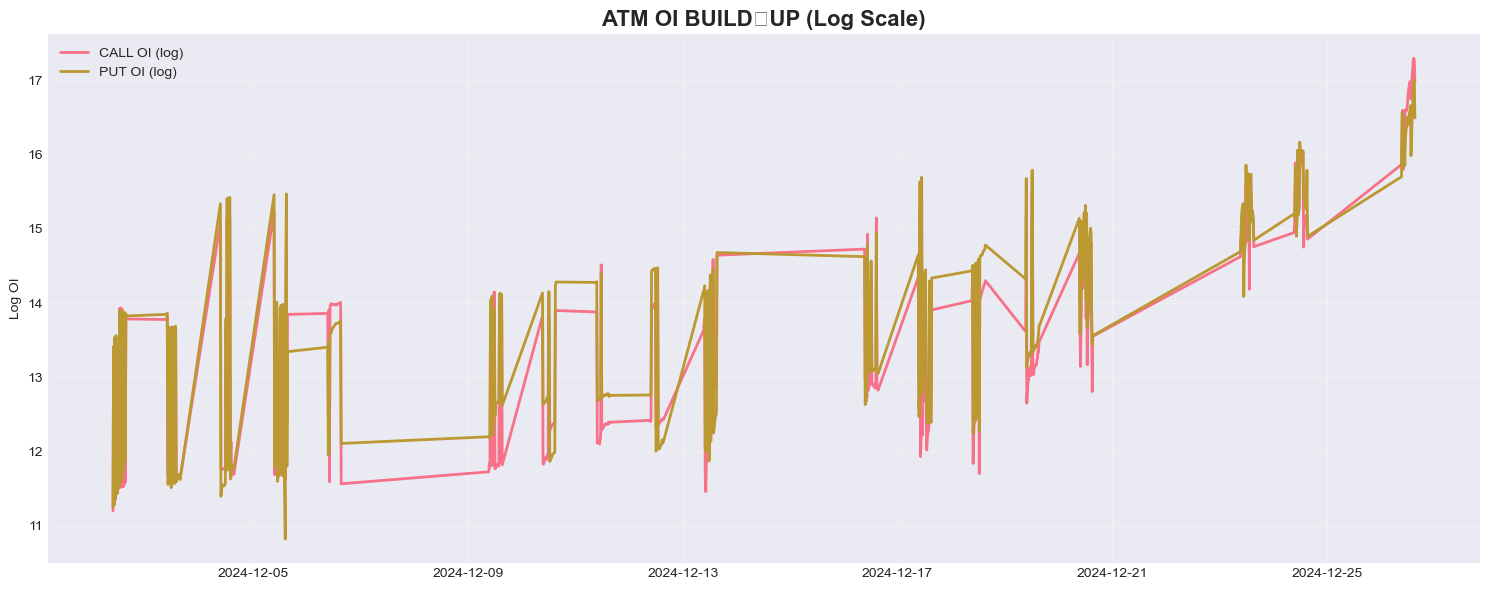

In [253]:
plt.figure(figsize=(15, 6))

# Log scale to see relative changes
df_log = df.copy()
df_log['CALL_oi_log'] = np.log1p(df_log['CALL_oi'])
df_log['PUT_oi_log']  = np.log1p(df_log['PUT_oi'])

plt.plot(df_log.set_index('datetime')['CALL_oi_log'], label='CALL OI (log)', linewidth=2)
plt.plot(df_log.set_index('datetime')['PUT_oi_log'], label='PUT OI (log)', linewidth=2)
plt.title('ATM OI BUILD‑UP (Log Scale)', fontsize=16, fontweight='bold')
plt.ylabel('Log OI')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

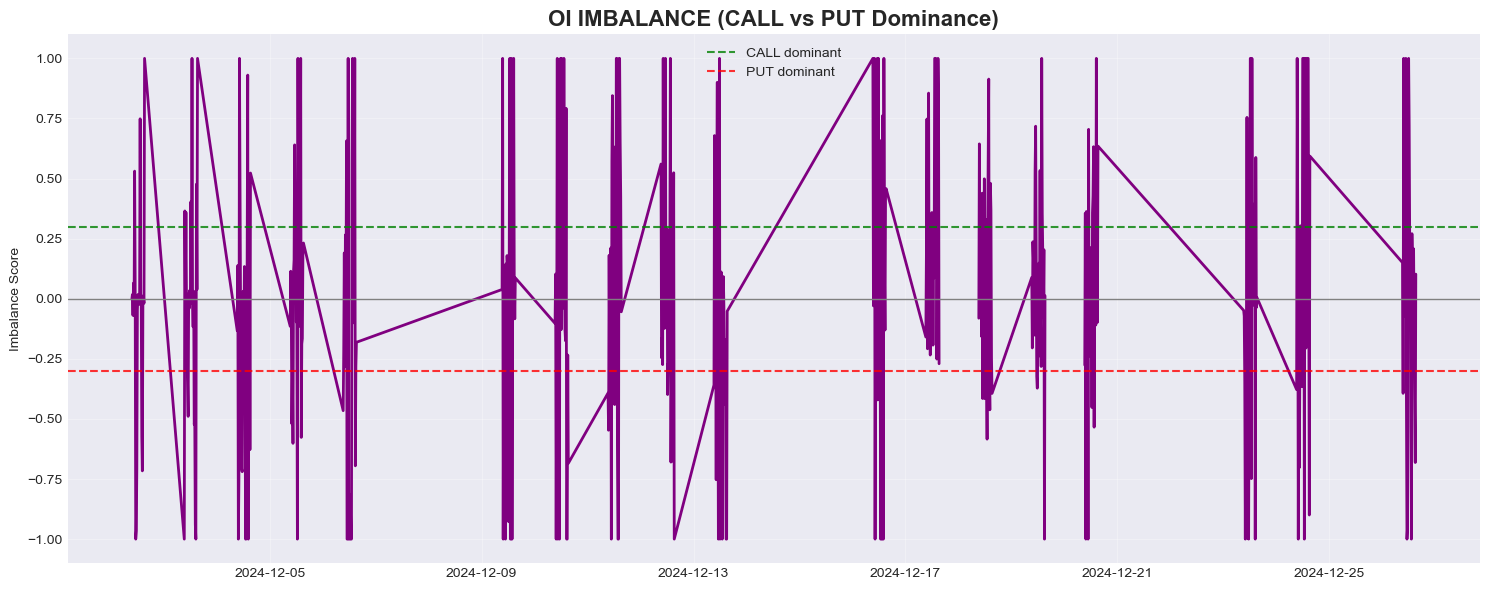

In [254]:
plt.figure(figsize=(15, 6))

plt.plot(df.set_index('datetime')['oi_imbalance'], linewidth=2, color='purple')
plt.axhline(0.3, color='green', linestyle='--', alpha=0.8, label='CALL dominant')
plt.axhline(-0.3, color='red', linestyle='--', alpha=0.8, label='PUT dominant')
plt.axhline(0, color='grey', linewidth=1)
plt.title('OI IMBALANCE (CALL vs PUT Dominance)', fontsize=16, fontweight='bold')
plt.ylabel('Imbalance Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

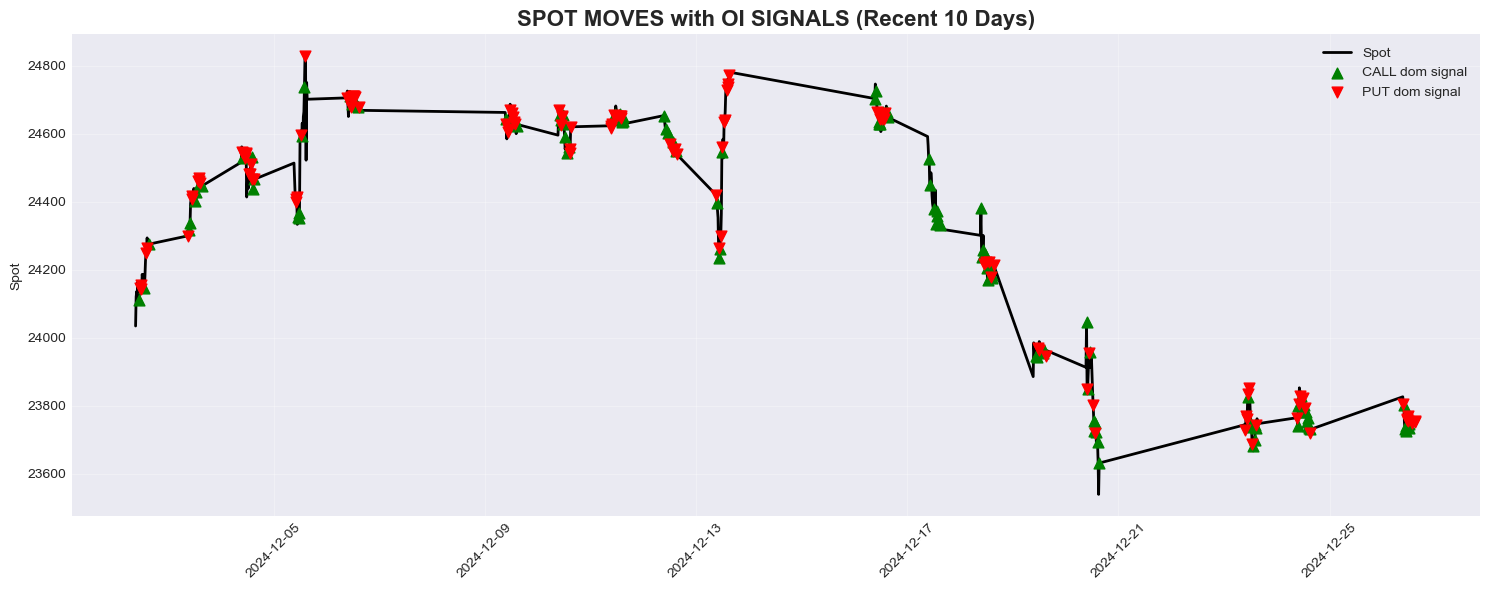

In [255]:
plt.figure(figsize=(15, 6))

# Recent data only (less cluttered)
recent = df.tail(672).reset_index(drop=True)  # ✅ RESET INDEX HERE
spot_recent = recent.set_index('datetime')['spot']

plt.plot(spot_recent.index, spot_recent.values, color='black', linewidth=2, label='Spot')

# Signals (on reset recent df)
call_sig = recent['oi_imbalance'] > 0.3
put_sig  = recent['oi_imbalance'] < -0.3

plt.scatter(spot_recent.index[call_sig], spot_recent.values[call_sig], 
            marker='^', color='green', s=60, label='CALL dom signal', zorder=5)
plt.scatter(spot_recent.index[put_sig], spot_recent.values[put_sig], 
            marker='v', color='red', s=60, label='PUT dom signal', zorder=5)

plt.title('SPOT MOVES with OI SIGNALS (Recent 10 Days)', fontsize=16, fontweight='bold')
plt.ylabel('Spot')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

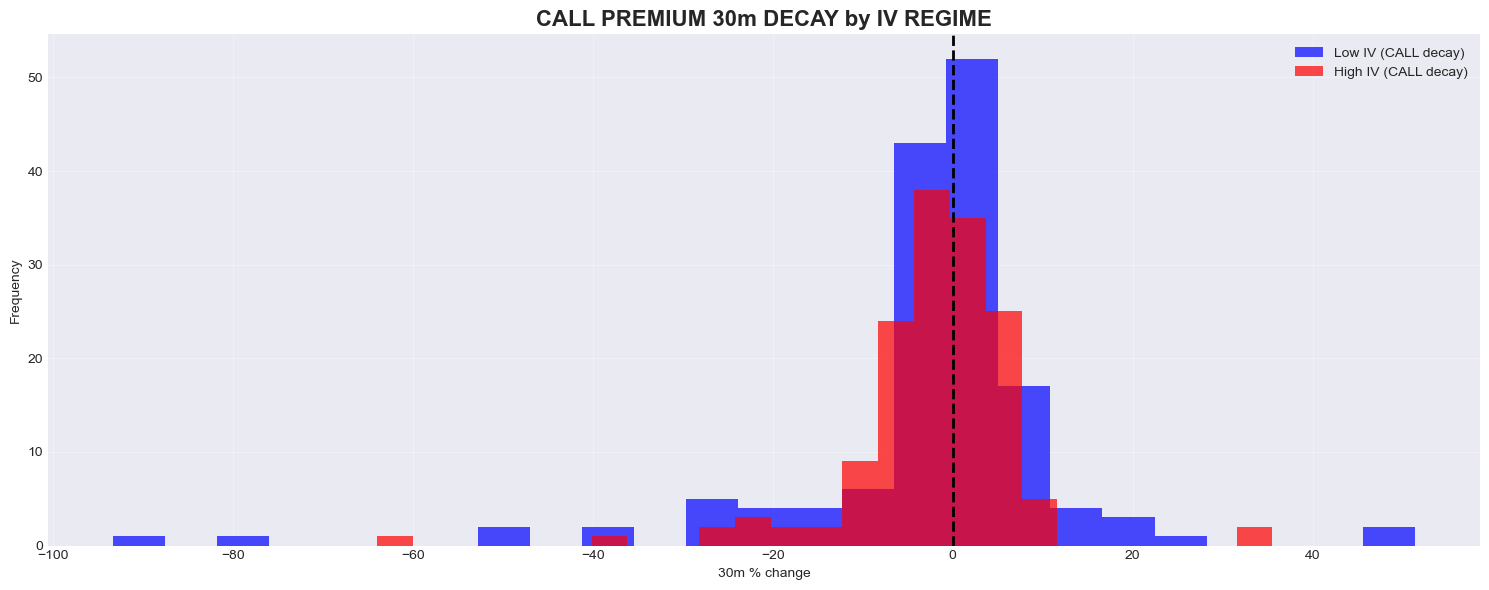

In [256]:
plt.figure(figsize=(15, 6))

low_iv = df['CALL_iv'] < df['CALL_iv'].quantile(0.33)
high_iv = df['CALL_iv'] > df['CALL_iv'].quantile(0.67)

plt.hist(df[low_iv]['call_ret_30m'], bins=25, alpha=0.7, label='Low IV (CALL decay)', color='blue')
plt.hist(df[high_iv]['call_ret_30m'], bins=25, alpha=0.7, label='High IV (CALL decay)', color='red')
plt.axvline(0, color='black', linestyle='--', linewidth=2)
plt.title('CALL PREMIUM 30m DECAY by IV REGIME', fontsize=16, fontweight='bold')
plt.xlabel('30m % change')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

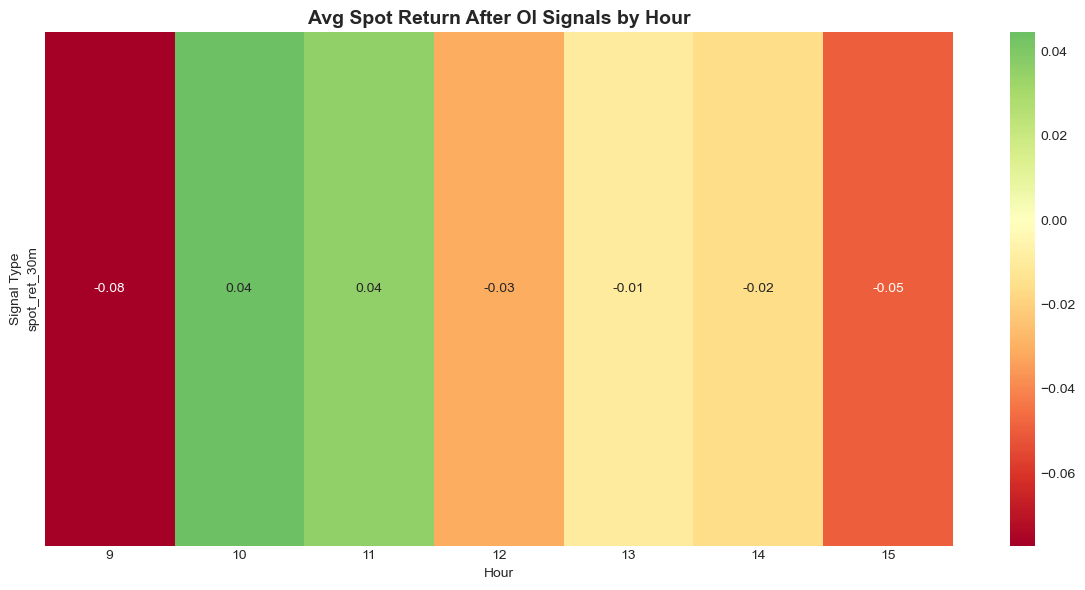

In [257]:
import seaborn as sns

# OI signal strength by time
df_sig_time = df[df['oi_imbalance'].abs() > 0.3].copy()
df_sig_time['hour'] = df_sig_time['datetime'].dt.hour

plt.figure(figsize=(12, 6))
time_pivot = df_sig_time.pivot_table(
    values='spot_ret_30m', 
    index='hour', 
    aggfunc='mean'
)
sns.heatmap(time_pivot.T, annot=True, cmap='RdYlGn', center=0, fmt='.2f')
plt.title('Avg Spot Return After OI Signals by Hour', fontsize=14, fontweight='bold')
plt.xlabel('Hour')
plt.ylabel('Signal Type')
plt.tight_layout()
plt.show()